In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [7]:
print(trimmed.columns)

Index(['Dropout (1=Yes 0=No)', 'Entry Year', 'Performance Bucket',
       'Pass Rate Semester A (%)', 'Pass Rate Semester B (%)',
       'Pass Rate Last Year (%)', 'Credits Passed Normal',
       'Credits Passed Sem A', 'Credits Passed Sem B',
       'Credits Enrolled Total', 'Platform Days Logged (Total)',
       'Campus WiFi Days (Total)'],
      dtype='str')


In [10]:
data22 = pd.read_csv(r"../Data/dropout_clean_2022.csv")
trimmed = pd.read_csv(r"../Data/dropout_clean_trimmed.csv")
trimmed.rename(columns={"Platform Days Logged (Total)": "Poliformat Days Logged (Total)"}, inplace=True)
data22 = data22[trimmed.columns.to_list()].drop(columns = "Entry Year")
data22.info()

<class 'pandas.DataFrame'>
RangeIndex: 20427 entries, 0 to 20426
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Dropout (1=Yes 0=No)            20427 non-null  int64  
 1   Performance Bucket              19262 non-null  float64
 2   Pass Rate Semester A (%)        17284 non-null  float64
 3   Pass Rate Semester B (%)        19183 non-null  float64
 4   Pass Rate Last Year (%)         14551 non-null  float64
 5   Credits Passed Normal           20427 non-null  float64
 6   Credits Passed Sem A            20427 non-null  float64
 7   Credits Passed Sem B            20427 non-null  float64
 8   Credits Enrolled Total          20427 non-null  float64
 9   Poliformat Days Logged (Total)  13891 non-null  float64
 10  Campus WiFi Days (Total)        16672 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 1.7 MB


In [14]:
from sklearn.model_selection import train_test_split

X = data22.drop(columns="Dropout (1=Yes 0=No)")
y = data22["Dropout (1=Yes 0=No)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,          # reproducible
    stratify=y                # keeps dropout ratio equal in both splits
)

clf = tree.DecisionTreeClassifier()
clf.fit(X_train, y_train)
param_grid = {'max_leaf_nodes': range(2, clf.tree_.n_leaves + 1)}

In [15]:
clf_grid = GridSearchCV(clf, param_grid)

In [16]:
clf_grid.fit(data22.drop(columns = "Dropout (1=Yes 0=No)"), data22["Dropout (1=Yes 0=No)"]) 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_leaf_nodes': range(2, 1484)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate p

path = clf.cost_complexity_pruning_path(data22.drop(columns = "Dropout (1=Yes 0=No)"), data22["Dropout (1=Yes 0=No)"])

param_grid = {'ccp_alpha': path['ccp_alphas']}

clf_grid = GridSearchCV(clf, param_grid)

clf_grid.fit(data22.drop(columns = "Dropout (1=Yes 0=No)"), data22["Dropout (1=Yes 0=No)"]) 

In [17]:
columns = data22.columns.drop("Dropout (1=Yes 0=No)")

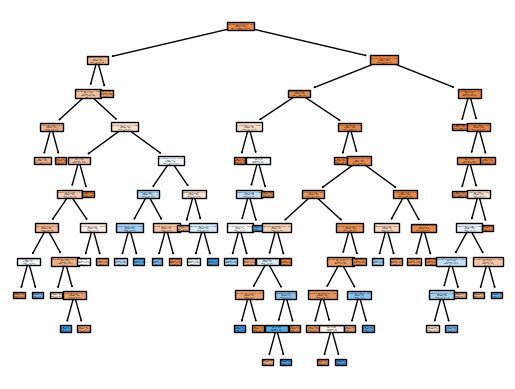

In [21]:
tree.plot_tree(clf_grid.best_estimator_, feature_names=columns, class_names = ["0", "1"], filled = True)
# Source - https://stackoverflow.com/a/39870740
# Posted by Ohad Eytan, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-24, License - CC BY-SA 4.0

plt.savefig('../Figures/BestTreeTrimmed1.png', dpi=1500)

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = clf_grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97      3787
           1       0.76      0.24      0.37       299

    accuracy                           0.94      4086
   macro avg       0.85      0.62      0.67      4086
weighted avg       0.93      0.94      0.92      4086

[[3764   23]
 [ 226   73]]
